In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
import joblib

In [2]:
dataset_url = 'data/weatherAUS.csv'
raw_df = pd.read_csv(dataset_url)

use_sample = False
sample_fraction = 0.1

if use_sample:
    raw_df = raw_df.sample(frac=sample_fraction).copy()
    
    
raw_df.dropna(subset=['RainToday', 'RainTomorrow'], inplace=True)

# Create training and test sets
year = pd.to_datetime(raw_df.Date).dt.year
train_df, test_df = raw_df[year < 2015], raw_df[year >= 2015]

# Create inputs and targets
input_cols = list(train_df.columns)[1:-1]
target_col = 'RainTomorrow'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
test_inputs, test_targets = test_df[input_cols], test_df[target_col]

# Identify numeric and categorical columns
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist() #[:-1]
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Base pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Parameter distributions
param_dist = {
    'classifier__n_estimators': randint(20, 120),
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': randint(2, 100),
    'classifier__min_samples_leaf': randint(10, 80),
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', None]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

from sklearn.metrics import make_scorer, f1_score

f1 = make_scorer(f1_score, pos_label='Yes')

# Random Search
random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_dist,
    n_iter=40,          # кількість випадкових комбінацій
    cv=cv,
    scoring=f1,       # або 'roc_auc' для незбалансованих класів
    n_jobs=-1,
    random_state=42,
    verbose=1,
    error_score='raise'
)

random_search.fit(train_inputs, train_targets)

best_model = random_search.best_estimator_

print("Best hyperparameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)


Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best hyperparameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 24, 'classifier__min_samples_split': 73, 'classifier__n_estimators': 80}
Best score: 0.6203451395562906


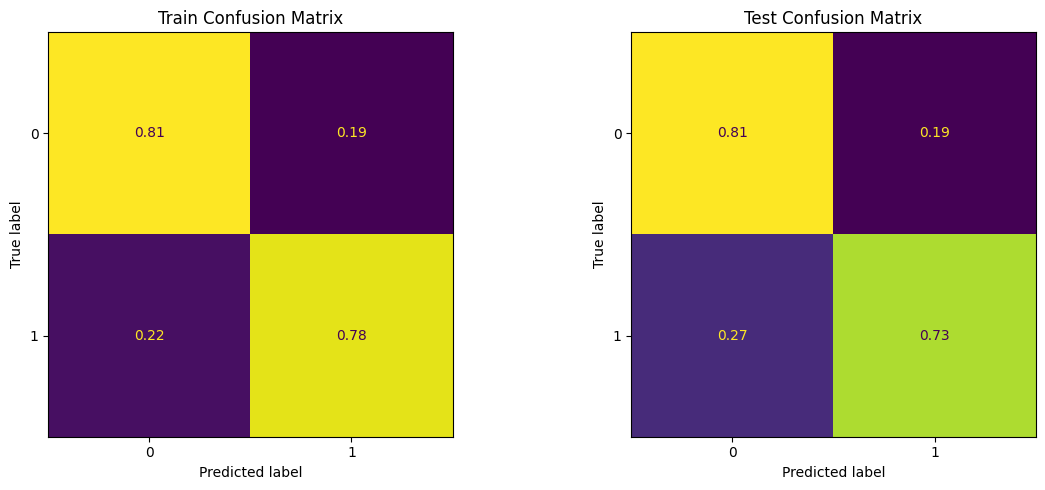

Звіт класифікації на тестовій вибірці:
              precision    recall  f1-score   support

          No     0.9143    0.8065    0.8570     33396
         Yes     0.5156    0.7314    0.6048      9403

    accuracy                         0.7900     42799
   macro avg     0.7149    0.7689    0.7309     42799
weighted avg     0.8267    0.7900    0.8016     42799



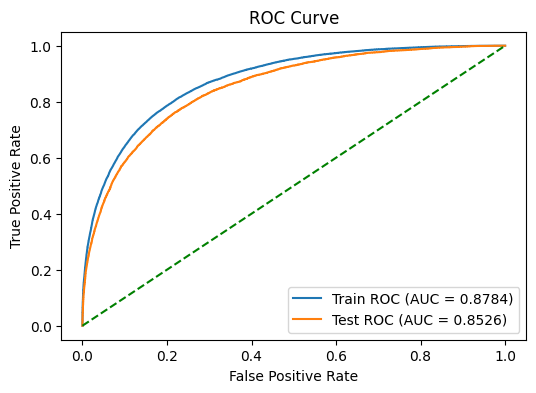

In [6]:
# best_params_ з random_search
best_params = random_search.best_params_

# Створюємо фінальний pipeline з кращими параметрами
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=best_params['classifier__n_estimators'],
        max_depth=best_params['classifier__max_depth'],
        min_samples_split=best_params['classifier__min_samples_split'],
        min_samples_leaf=best_params['classifier__min_samples_leaf'],
        max_features=best_params['classifier__max_features'],
        class_weight=best_params['classifier__class_weight'],
        random_state=42
    ))
])

# Навчаємо фінальну модель на всьому тренувальному наборі
final_model.fit(train_inputs, train_targets)

from metrics_utils import auroc_train_and_val, evaluate_classification_model
evaluate_classification_model(final_model, train_inputs, test_inputs, train_targets, test_targets)
auroc_train_and_val(final_model, train_inputs, test_inputs, train_targets, test_targets)

In [4]:
import joblib
joblib.dump(final_model, "model/rf_weather.pkl")

['model/rf_weather.pkl']

In [5]:
# Збереження діапазонів значень для використання в Streamlit
# Вибираємо ознаки
categorical_cols = raw_df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Date')  # дату пропускаємо
categorical_cols.remove('RainTomorrow')  # цільову змінну пропускаємо

numeric_cols = raw_df.select_dtypes(include=np.number).columns.tolist()

# Для категоріальних ознак — список всіх унікальних значень
categorical_options = {col: sorted(raw_df[col].dropna().unique().tolist()) for col in categorical_cols}

# Для числових ознак — мін, макс, медіана
numeric_stats = {}
for col in numeric_cols:
    numeric_stats[col] = {
        'min': float(raw_df[col].min()),
        'max': float(raw_df[col].max()),
        'median': float(raw_df[col].median())
    }

# Збережемо в один словник для Streamlit
defaults_for_streamlit = {
    'categorical_options': categorical_options,
    'numeric_stats': numeric_stats
}

# Збереження у файл
joblib.dump(defaults_for_streamlit, 'data/defaults_streamlit.pkl')

['data/defaults_streamlit.pkl']